## The PI-CAI data set 

PI-CAI (Prostate Imaging: Cancer AI) data set comes PI-CAI challenge (https://pi-cai.grand-challenge.org/PI-CAI/). It is composed of over 10,000 carefully-curated prostate MRI exams and clinical information. The goal of these challenge is to provide valuable data to help the development and validation of AI algorithms and standardize present-day guidelines (Reinke et al., 2022).

#### Abbreviation

- PCa: Prostate Cancer
- PSA: Prostate-Specific Antigen
- csPCa: Clinical Sigficant Prostate Cancer
- PSAD: Prostate-Specific Antigen Density
- BPH: Benign Prostatic Hyperplasia
- PI-CAI: Prostate Imaging - Cancer AI
- ISUP: International Society of Urological Pathology grade 


In [ ]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## The PI-CAI data set summary 

In [71]:
# Load Clinical Information
picai_clinical = pd.read_csv("picai_labels/clinical_information/marksheet.csv")

picai_clinical.drop(columns=["patient_id", "study_id"], 
                    errors="ignore").head()

,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center
0,2019-07-02,73,7.7,NaN,55.0,MRBx,0+0,0,0,NO,PCNN
1,2016-05-27,64,8.7,0.09,102.0,NaN,NaN,NaN,0,NO,RUMC
2,2021-04-18,58,4.2,0.06,74.0,NaN,NaN,NaN,0,NO,ZGT
3,2019-04-05,72,13.0,NaN,71.5,SysBx,0+0,0,0,NO,ZGT
4,2020-10-21,67,8.0,0.10,78.0,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC


In [ ]:
# Get summary information about the dataset
picai_clinical.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       1500 non-null   int64  
 1   study_id         1500 non-null   int64  
 2   mri_date         1500 non-null   str    
 3   patient_age      1500 non-null   int64  
 4   psa              1460 non-null   float64
 5   psad             1049 non-null   float64
 6   prostate_volume  1473 non-null   float64
 7   histopath_type   1001 non-null   str    
 8   lesion_GS        1001 non-null   str    
 9   lesion_ISUP      1001 non-null   str    
 10  case_ISUP        1500 non-null   int64  
 11  case_csPCa       1500 non-null   str    
 12  center           1500 non-null   str    
dtypes: float64(3), int64(4), str(6)
memory usage: 152.5 KB


The PI-CAI data set is composed of 1500 observation and 13 attributes, plus 2 identity attibutes (patient_id and study_id). Of these, five attibutes are numerical (patient_age, psa, psad, prostate_volume, histopath_type, case_ISUP), while 6 are categorical (mri_date, histopath_type, lesion_GS, lesion_ISUP, case_csPCa, center). 

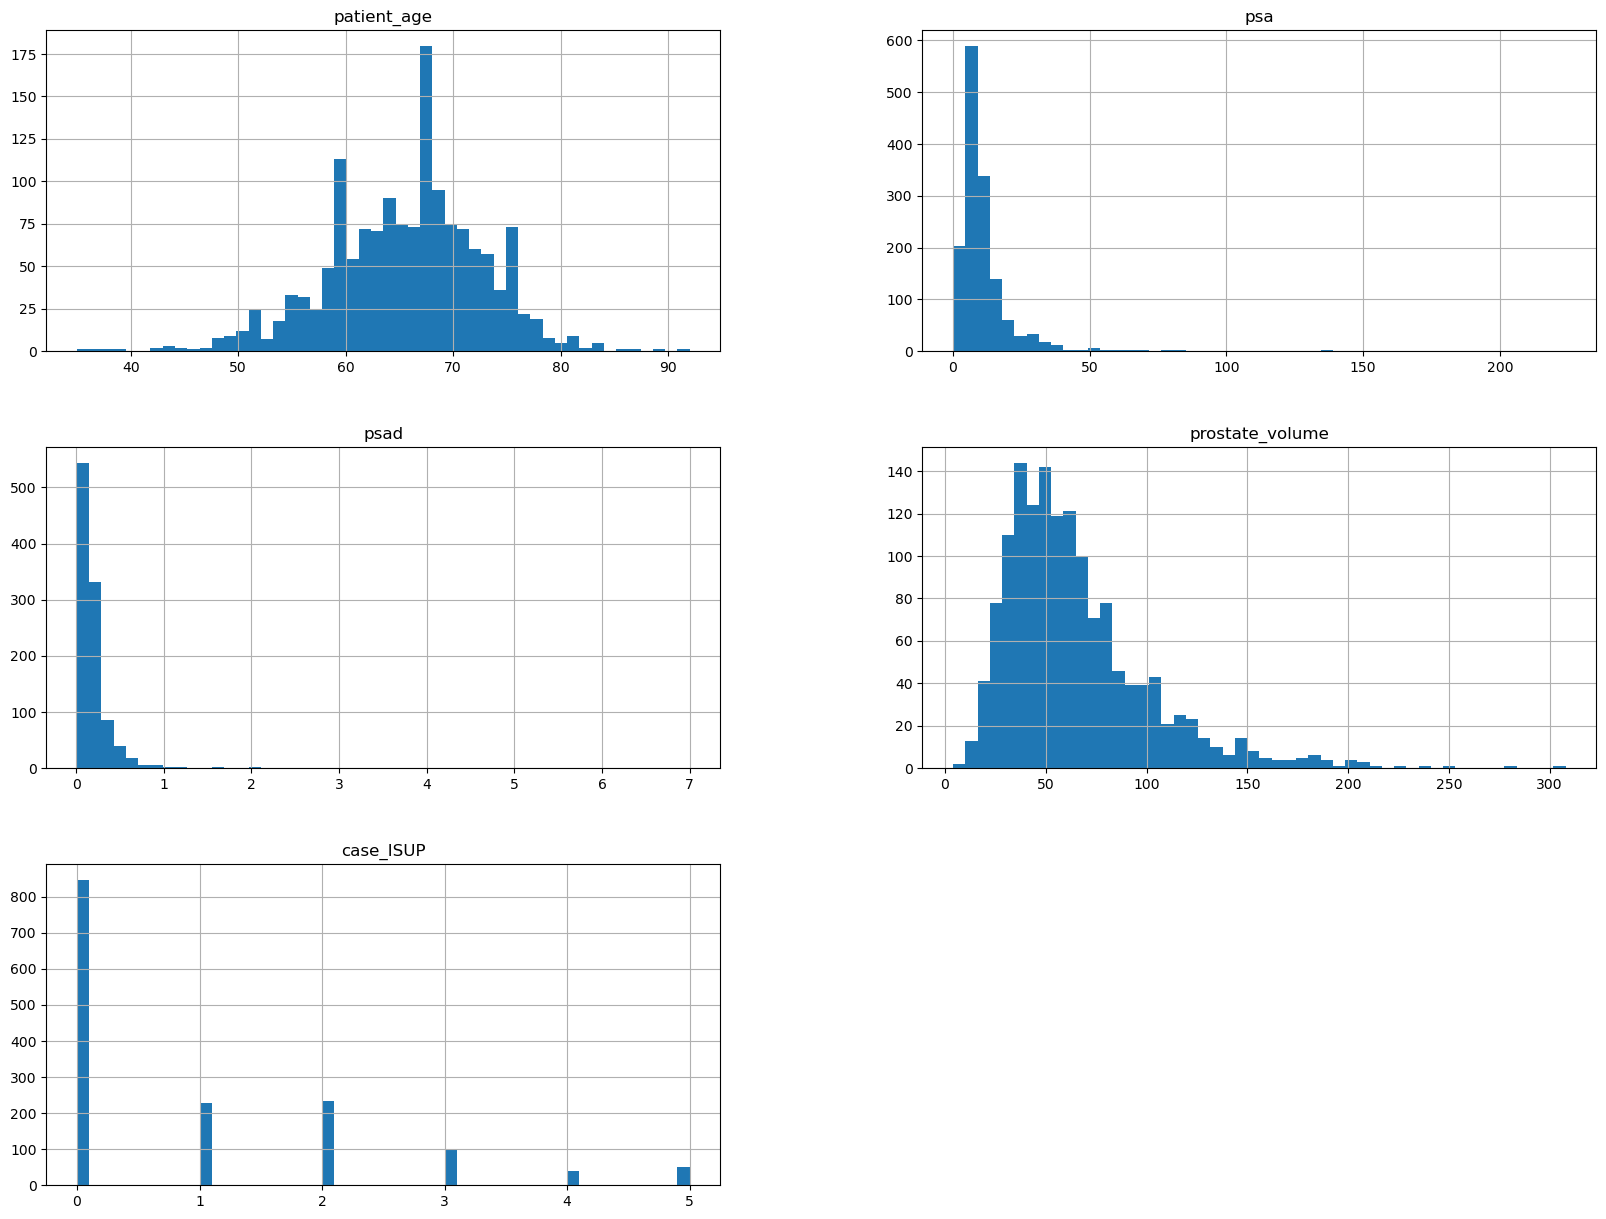

In [ ]:
import matplotlib.pyplot as plt

# Plot histogram for all numerical attributes
picai_clinical.drop(columns=["patient_id", "study_id"], 
                    errors="ignore").hist(bins=50, 
                                          figsize=(20,15))

plt.show()

In [72]:
picai_clinical.drop(columns=["patient_id", "study_id"], 
                    errors="ignore").describe()

,patient_age,psa,psad,prostate_volume,case_ISUP
count,1500.000000,1460.000000,1049.000000,1473.000000,1500.000000
mean,65.595333,11.932397,0.224662,65.045472,0.942000
std,7.191527,14.939071,0.404288,36.449618,1.333099
min,35.000000,0.100000,0.010000,4.000000,0.000000
25%,61.000000,5.882500,0.090000,40.000000,0.000000
50%,66.000000,8.500000,0.140000,57.000000,0.000000
75%,70.000000,13.000000,0.220000,80.000000,2.000000
max,92.000000,224.000000,7.000000,308.000000,5.000000


In [81]:
n_patients = len(picai_clinical)
isup_counts = picai_clinical["case_ISUP"].value_counts().sort_index()

pd.DataFrame({"n_patients": n_patients, 
              "isup_counts": isup_counts,
              "%_patients": (isup_counts / n_patients * 100).round(2)})

,n_patients,isup_counts,%_patients
case_ISUP,,,
0,1500,847,56.47
1,1500,228,15.20
2,1500,234,15.60
3,1500,99,6.60
4,1500,40,2.67
5,1500,52,3.47


In [80]:
n_patients = len(picai_clinical)
case_csPCa = picai_clinical["case_csPCa"].value_counts().sort_index()

pd.DataFrame({"case_csPCa": case_csPCa,
             "%_patients": (case_csPCa / n_patients * 100).round(2)})

,case_csPCa,%_patients
case_csPCa,,
NO,1075,71.67
YES,425,28.33


The histogram of the numerical attibutes display different patterns. The cohort age exhibit a diverse distribution with a bell-shaped distributions (mean = 65.59, std = 7.19, min = 35, max = 92). The PSA levels of the cohort is right skewed (unit: mL), with mean = 11.93 (std = 14.93, min = 0.10, max = 92). The PSAD (unit: ng/mL²), a index that uses serum PSA and prostate volume to better distinguish between BPH and PCa, is right skewed (mean = 0.22, std = 0.4), with values ranging from 0.01 to 7. The total number of ISUP-based lesions show that most of the lesions are ISUP 0 (56.4%), while the intermediate grades show more diverse values, and low number of high grade ISUP 4 (2.6%) and 5 (3.4%). The data set has one categorical (str) feature called `case_csPCa`. This variable has two
categories (Targets), YES - csPCa  (n = 425, 28.33%), and NO - no csPCa (n = 1075, 71.6%).

## The PI-CAI data set correlations 

array([[<Axes: xlabel='psa', ylabel='psa'>,
        <Axes: xlabel='patient_age', ylabel='psa'>,
        <Axes: xlabel='prostate_volume', ylabel='psa'>,
        <Axes: xlabel='psad', ylabel='psa'>,
        <Axes: xlabel='case_ISUP', ylabel='psa'>],
       [<Axes: xlabel='psa', ylabel='patient_age'>,
        <Axes: xlabel='patient_age', ylabel='patient_age'>,
        <Axes: xlabel='prostate_volume', ylabel='patient_age'>,
        <Axes: xlabel='psad', ylabel='patient_age'>,
        <Axes: xlabel='case_ISUP', ylabel='patient_age'>],
       [<Axes: xlabel='psa', ylabel='prostate_volume'>,
        <Axes: xlabel='patient_age', ylabel='prostate_volume'>,
        <Axes: xlabel='prostate_volume', ylabel='prostate_volume'>,
        <Axes: xlabel='psad', ylabel='prostate_volume'>,
        <Axes: xlabel='case_ISUP', ylabel='prostate_volume'>],
       [<Axes: xlabel='psa', ylabel='psad'>,
        <Axes: xlabel='patient_age', ylabel='psad'>,
        <Axes: xlabel='prostate_volume', ylabel='psad'>,
 

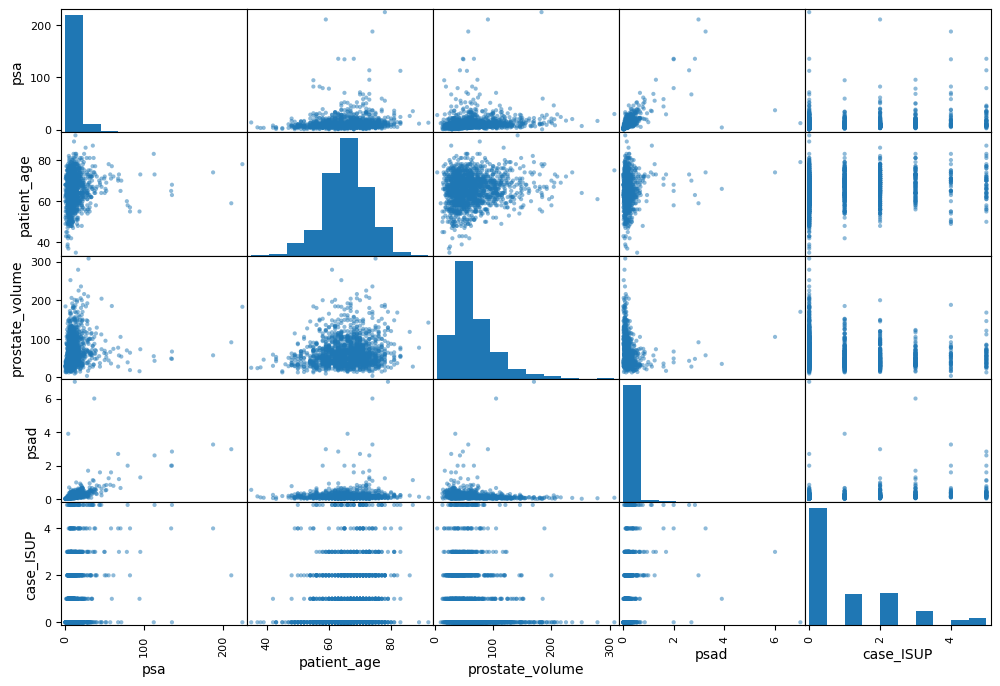

In [ ]:
from pandas.plotting import scatter_matrix


attributes = ["psa", "patient_age", 
              "prostate_volume", 
              "psad", "case_ISUP"]

scatter_matrix(picai_clinical[attributes], 
               figsize=(12, 8))

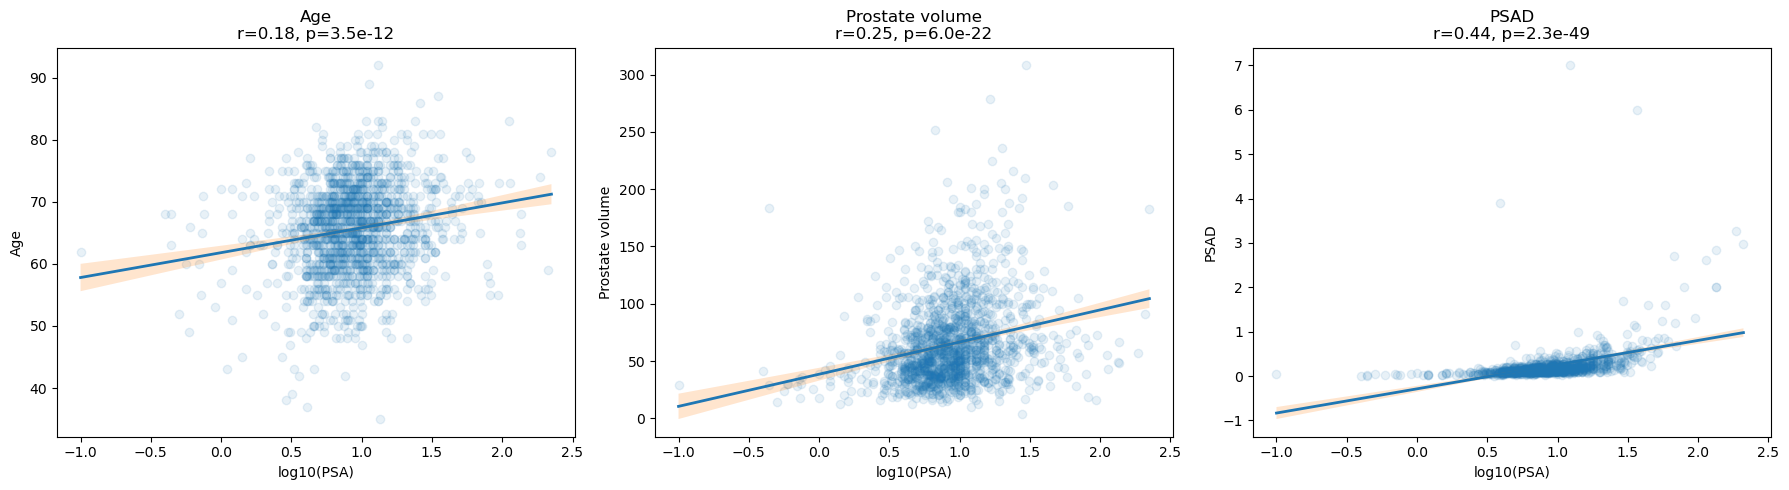

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr

plots = [
    ("patient_age", "Age"),
    ("prostate_volume", "Prostate volume"),
    ("psad", "PSAD"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ax, (ycol, ylabel) in zip(axes, plots):
    df = picai_clinical[["psa", ycol]].dropna()
    df = df[df["psa"] > 0]

    x = np.log10(df["psa"].to_numpy())
    y = df[ycol].to_numpy()

    # scatter
    ax.scatter(x, y, alpha=0.1)

    # linear fit + 95% CI
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_pred = np.linspace(x.min(), x.max(), 200)
    X_pred = sm.add_constant(x_pred)
    pred = model.get_prediction(X_pred)
    ci = pred.conf_int(alpha=0.05)

    ax.plot(x_pred, pred.predicted_mean, linewidth=2)
    ax.fill_between(x_pred, ci[:, 0], ci[:, 1], alpha=0.2)

    # correlation
    r, p = pearsonr(x, y)
    ax.set_title(f"{ylabel}\nr={r:.2f}, p={p:.1e}")

    ax.set_xlabel("log10(PSA)")
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Prostate Volume')

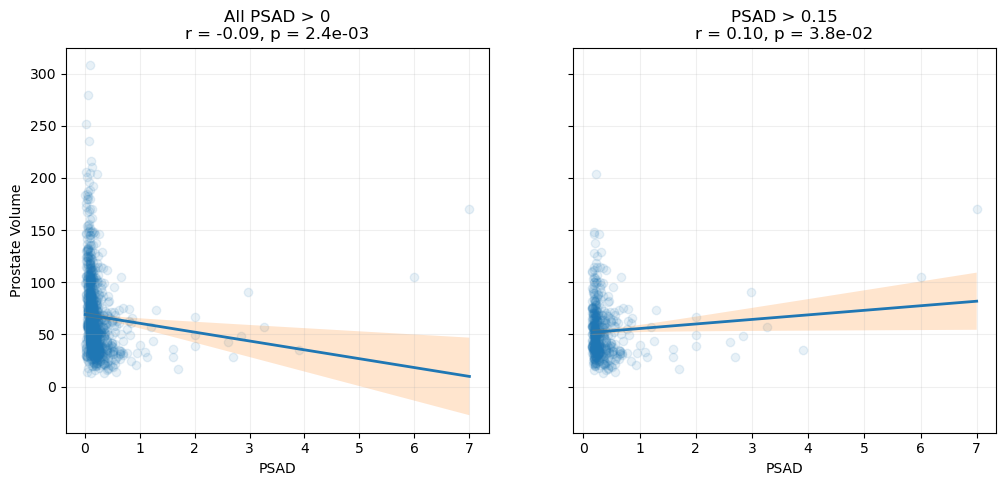

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr

filters = [
    ("All PSAD > 0",  picai_clinical["psad"] > 0),
    ("PSAD > 0.15",   picai_clinical["psad"] > 0.15),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (label, mask) in zip(axes, filters):
    df = picai_clinical.loc[mask, ["psad", "prostate_volume"]].dropna()

    x = df["psad"].to_numpy()
    y = df["prostate_volume"].to_numpy()

    # scatter
    ax.scatter(x, y, alpha=0.1)

    # linear regression + CI
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_pred = np.linspace(x.min(), x.max(), 200)
    X_pred = sm.add_constant(x_pred)
    pred = model.get_prediction(X_pred)
    ci = pred.conf_int(alpha=0.05)

    ax.plot(x_pred, pred.predicted_mean, linewidth=2)
    ax.fill_between(x_pred, ci[:, 0], ci[:, 1], alpha=0.2)

    # correlation
    r, p = pearsonr(x, y)
    ax.set_title(f"{label}\nr = {r:.2f}, p = {p:.1e}")

    ax.set_xlabel("PSAD")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Prostate Volume")

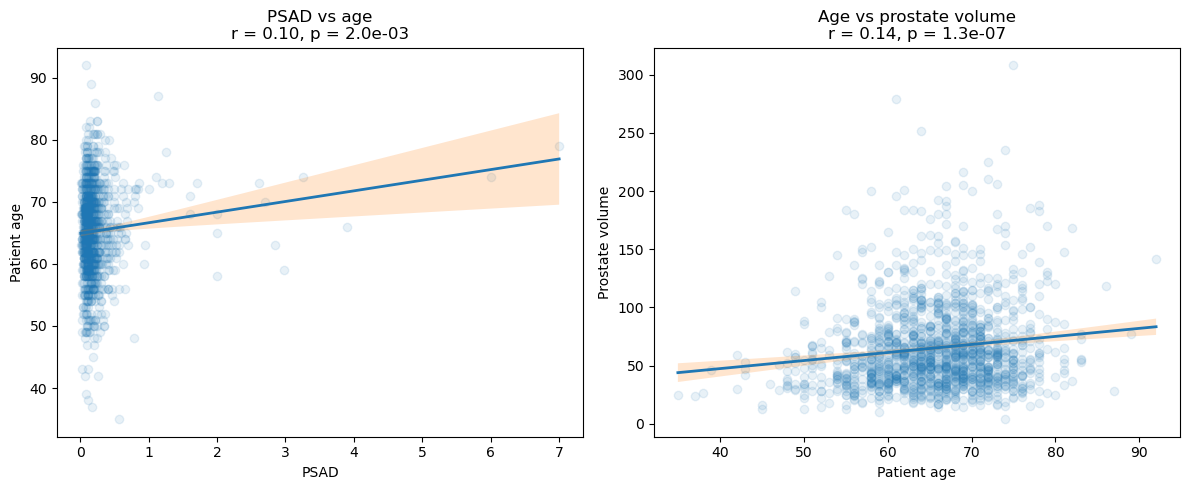

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- Panel A: PSAD vs patient age --------
df = picai_clinical[["psad", "patient_age"]].dropna()
df = df[df["psad"] > 0]

x = df["psad"].to_numpy()
y = df["patient_age"].to_numpy()

ax = axes[0]
ax.scatter(x, y, alpha=0.1)

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

x_pred = np.linspace(x.min(), x.max(), 200)
X_pred = sm.add_constant(x_pred)
pred = model.get_prediction(X_pred)
ci = pred.conf_int(alpha=0.05)

ax.plot(x_pred, pred.predicted_mean, linewidth=2)
ax.fill_between(x_pred, ci[:, 0], ci[:, 1], alpha=0.2)

r, p = pearsonr(x, y)
ax.set_title(f"PSAD vs age\nr = {r:.2f}, p = {p:.1e}")
ax.set_xlabel("PSAD")
ax.set_ylabel("Patient age")

# -------- Panel B: Age vs prostate volume --------
df = picai_clinical[["patient_age", "prostate_volume"]].dropna()

x = df["patient_age"].to_numpy()
y = df["prostate_volume"].to_numpy()

ax = axes[1]
ax.scatter(x, y, alpha=0.1)

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

x_pred = np.linspace(x.min(), x.max(), 200)
X_pred = sm.add_constant(x_pred)
pred = model.get_prediction(X_pred)
ci = pred.conf_int(alpha=0.05)

ax.plot(x_pred, pred.predicted_mean, linewidth=2)
ax.fill_between(x_pred, ci[:, 0], ci[:, 1], alpha=0.2)

r, p = pearsonr(x, y)
ax.set_title(f"Age vs prostate volume\nr = {r:.2f}, p = {p:.1e}")
ax.set_xlabel("Patient age")
ax.set_ylabel("Prostate volume")

plt.tight_layout()
plt.show()

The correlation between numerical atributes showed a range of correlation patterns. PSA value was small positive correlated with `patient_age` (R = 0.18, p = 3.47e-12), `prostate_volume` (R = 0.25, p = 6.04e-22), and higher positive correlation with `PSAD` (R = 0.44, p=2.25e-49). Patient age and prostate volume also showed a small positive correlation (R = 0.14, p=1.33e-07). Interesting,  `PSAD` showed variable corralation with `prostate_volume`, with negative correlation for `PSAD` and `prostate_volume` when all `PSDA` values were used, but with a small positive correlation for values above 0.15 ng/mL², which is a common cutoff used to distinguish BPH and PCa. Patient age also showed small positive correlation with PSAD (R = 0.1, 2.0e-03) and prostate volume (R = 0.14, 1.3e-07). 

## The PI-CAI data set images 